# Supply Chain Shipment Pricing - Exploratory Data Analysis  

In [1]:
# Import Libraries 

import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as ticker
import numpy  as  np
from dotenv import load_dotenv
load_dotenv(override=True)







True

In [ ]:
# Connect Database and Load Data 

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print ( ' Database Connection is done. ')

df = pd.read_sql("SELECT * FROM clean_shipment_pricing;", engine)
print(f"Loaded {len(df)} rows and {len(df.columns)} columns from clean_shipment_pricing")

print ( ' Data is Loaded From Database')
# Make a folder for output charts
# os.makedirs("outputs", exist_ok=True)


Loaded 6000 rows and 38 columns from clean_shipment_pricing
 Data is Loaded From Database


In [3]:
# Dataset Structure 

print("\n Shape :")
print(df.shape)

print("\n Data Info :")
print(df.info())


 Shape :
(6000, 38)

 Data Info :
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            6000 non-null   int64  
 1   project_code                  6000 non-null   str    
 2   pq_number                     6000 non-null   str    
 3   po_so_number                  6000 non-null   str    
 4   asn_dn_number                 5713 non-null   str    
 5   country                       6000 non-null   str    
 6   managed_by                    6000 non-null   str    
 7   fulfill_via                   6000 non-null   str    
 8   vendor_inco_term              6000 non-null   str    
 9   shipment_mode                 6000 non-null   str    
 10  pq_first_sent_to_client_date  6000 non-null   object 
 11  po_sent_to_vendor_date        6000 non-null   object 
 12  scheduled_delivery_date       6000 non

In [4]:
# Missing / Null Values Check 

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(by="missing_pct", ascending=False)
print("\n Missing values Summary :")
print(missing_summary)



 Missing values Summary :
                          missing_count  missing_pct
freight_cost_per_kg                 818        13.63
weight_kilograms                    480         8.00
freight_cost_usd                    360         6.00
freight_pct_of_value                360         6.00
is_on_time                          300         5.00
actual_lead_time_days               300         5.00
delivery_recorded_date              300         5.00
delivered_to_client_date            300         5.00
asn_dn_number                       287         4.78
line_item_insurance_usd             180         3.00
unit_price                           10         0.17
line_item_quantity                    8         0.13


In [5]:
# Statistics Summary 

numeric_cols = [
    "line_item_quantity", "line_item_value", "unit_price", "pack_price",
    "weight_kilograms", "freight_cost_usd", "freight_pct_of_value",
    "actual_lead_time_days", "planned_lead_time_days"
]
print("\n Summary statistics : ")
print(df[numeric_cols].describe().round(2))


 Summary statistics : 
       line_item_quantity  line_item_value  unit_price  pack_price  \
count             5992.00          6000.00     5990.00     6000.00   
mean             13431.74        304779.02       22.54      338.96   
std              16924.94        479005.20       12.96      292.60   
min                500.00            67.45        0.06        0.19   
25%               1000.00         20417.61       11.28       97.86   
50%               5000.00         78731.10       22.57      252.07   
75%              25000.00        363490.50       33.58      524.79   
max              50000.00       2247060.00       45.00     1300.58   

       weight_kilograms  freight_cost_usd  freight_pct_of_value  \
count           5520.00           5640.00               5640.00   
mean             138.35          30387.11                  9.87   
std              210.25          55375.21                  4.64   
min                0.51              1.35                  2.00   
25%       

In [6]:
# Outlier Check ( IQR Method )

def count_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

print("\n Outlier counts (IQR method) : ")
for col in ["unit_price", "line_item_value", "freight_cost_usd", "actual_lead_time_days"]:
    n_outliers = count_outliers_iqr(df[col].dropna())
    print(f"{col}: {n_outliers} potential outliers out of {df[col].notnull().sum()} values")


 Outlier counts (IQR method) : 
unit_price: 0 potential outliers out of 5990 values
line_item_value: 723 potential outliers out of 6000 values
freight_cost_usd: 683 potential outliers out of 5640 values
actual_lead_time_days: 2 potential outliers out of 5700 values


In [7]:
# Category Breakdown 

print("\n Shipments by country (top 10) :  ")
print(df["country"].value_counts().reset_index(name="shipments").head(10).to_string(index = False))

print("\n Shipments by shipment mode : ")
print(df["shipment_mode"].value_counts().reset_index(name="shipments").to_string(index = False))

print("\n Shipments by product group : ")
print(df["product_group"].value_counts().reset_index(name="shipments").head().to_string(index = False))


 Shipments by country (top 10) :  
   country  shipments
     Haiti        443
    Guyana        425
Mozambique        413
  Tanzania        408
  Zimbabwe        407
  Cameroon        403
    Zambia        403
    Uganda        399
   Vietnam        398
    Rwanda        397

 Shipments by shipment mode : 
shipment_mode  shipments
          Air       3305
        Ocean       1447
        Truck        630
  Air Charter        618

 Shipments by product group : 
product_group  shipments
          ACT       1236
         MRDT       1224
         ANTM       1221
         HRDT       1167
          ARV       1152


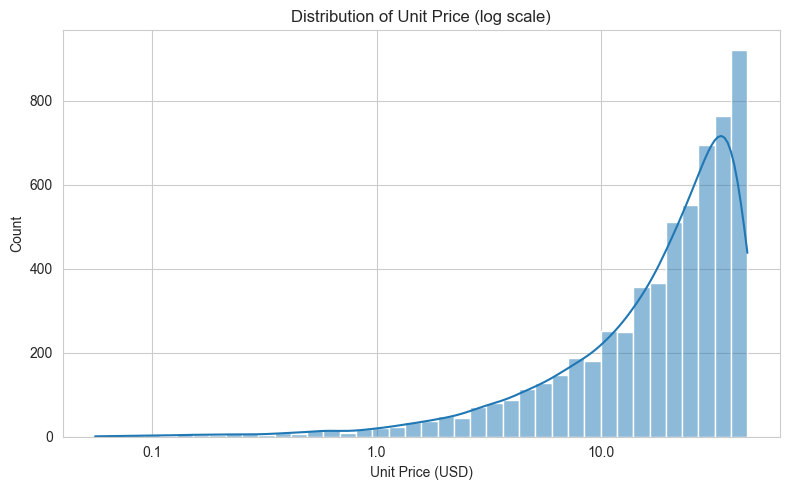

In [8]:
# Data Quality Check using Visuals


sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
# Distribution of unit price 
sns.histplot(df["unit_price"].dropna(), bins=40, log_scale=(True, False),ax = ax,kde= True)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter()) # Converts 10^1 -> 10
plt.title("Distribution of Unit Price (log scale)")
plt.xlabel("Unit Price (USD)")
plt.tight_layout()
plt.savefig("unit_price_distribution.png", dpi=120)
plt.show()
plt.close()



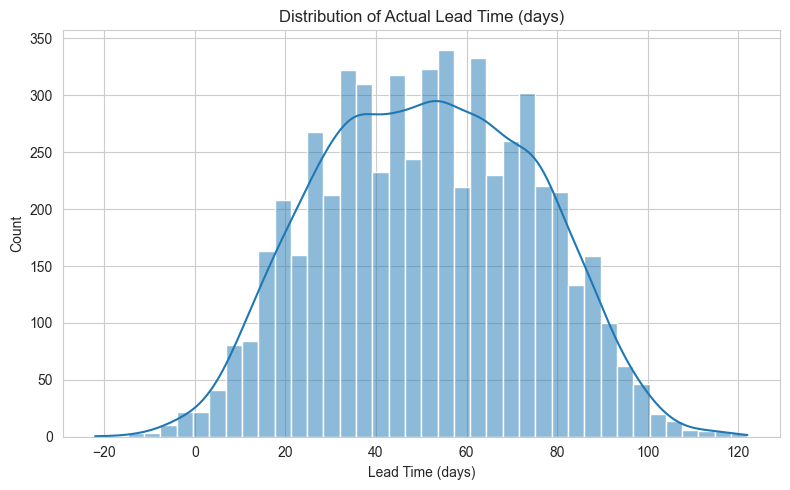

In [9]:

# Lead time distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["actual_lead_time_days"].dropna(),kde = True, bins=40)
plt.title("Distribution of Actual Lead Time (days)")
plt.xlabel("Lead Time (days)")
plt.tight_layout()
plt.savefig("lead_time_distribution.png", dpi=120)
plt.show()
plt.close()



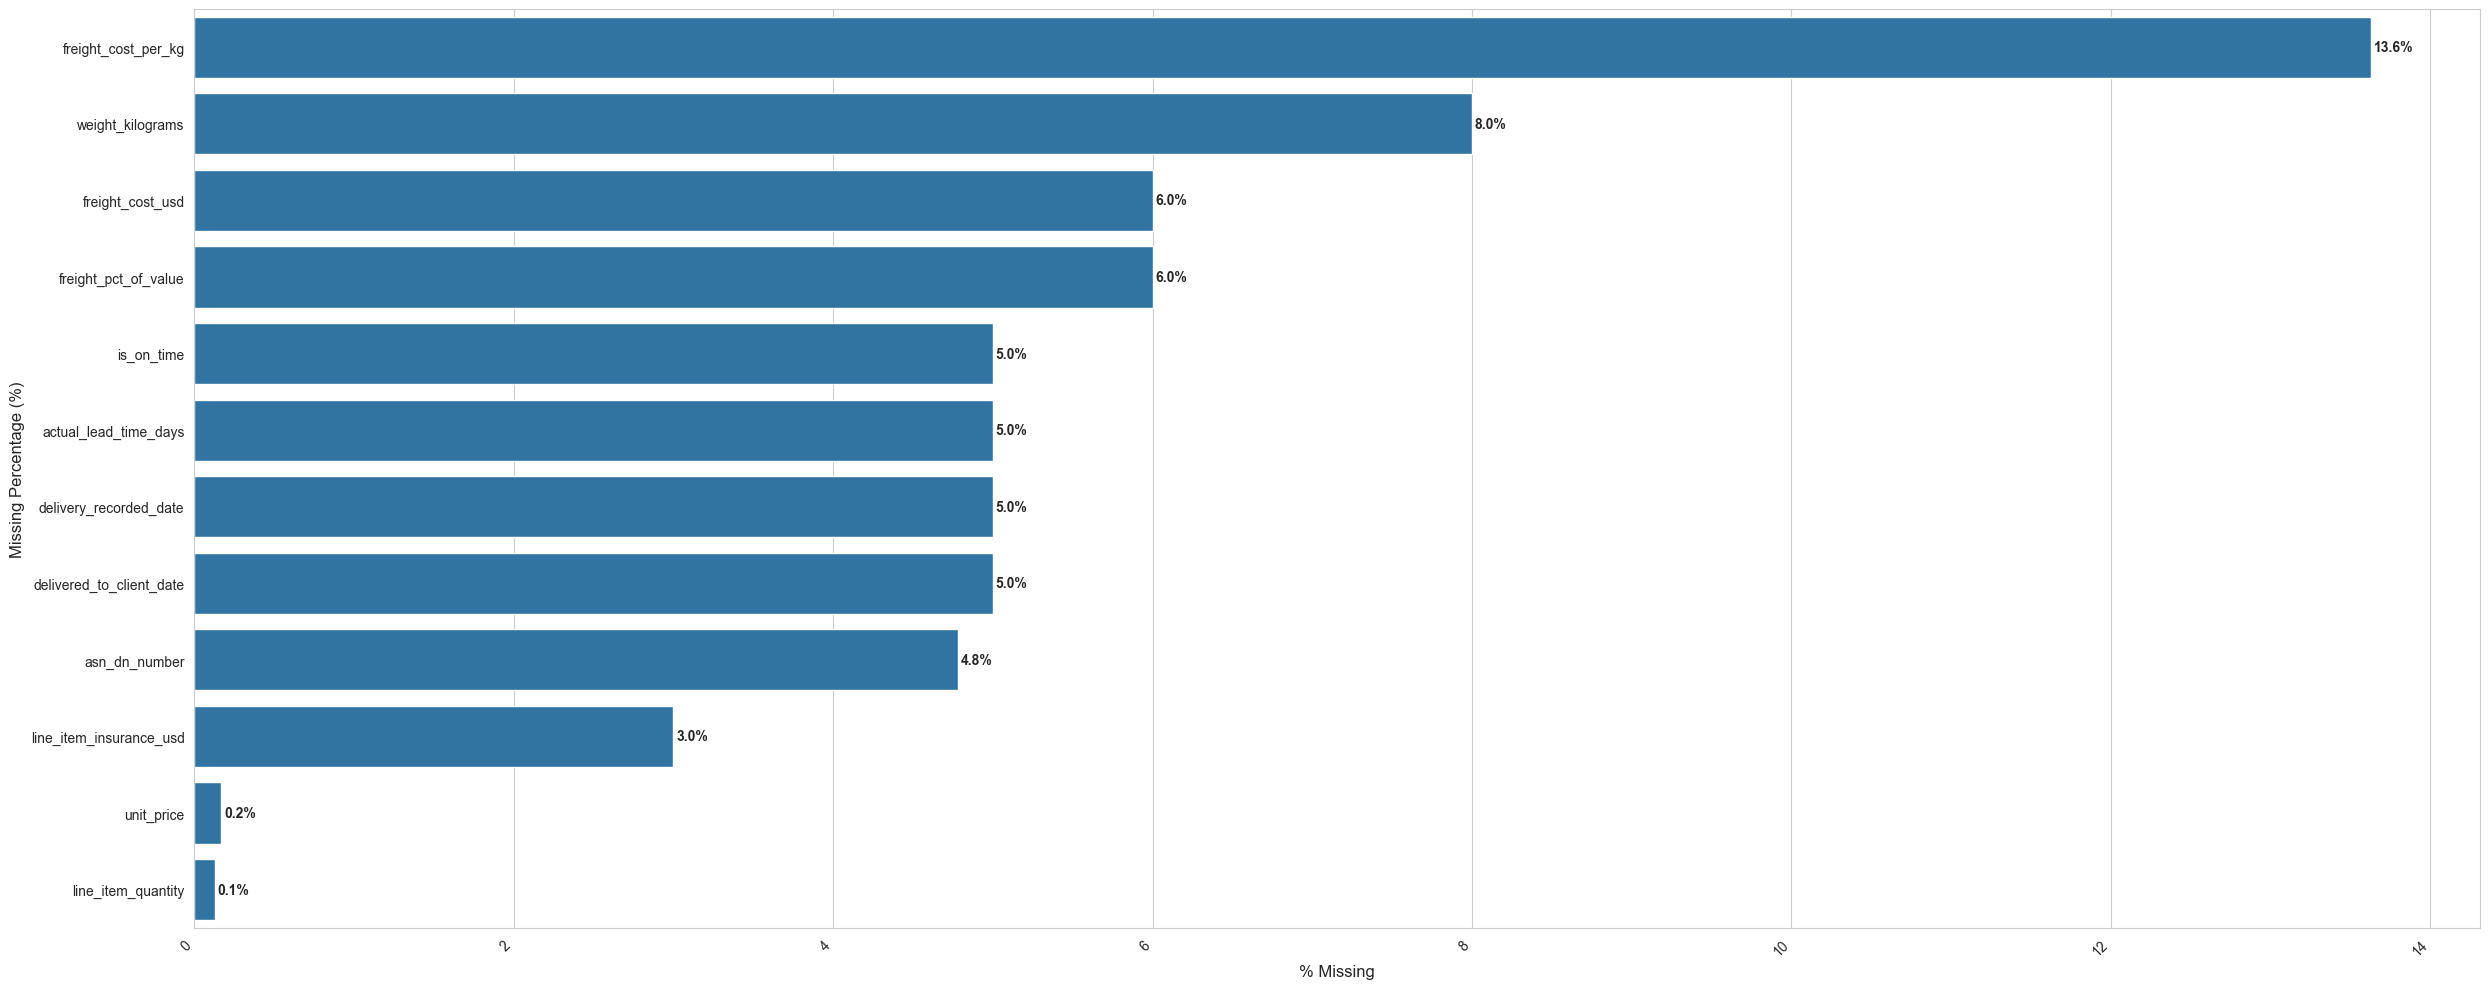

In [10]:
# Missing Pct

plt.figure(figsize=(25 ,10))
ax = sns.barplot(x=missing_summary["missing_pct"], y=missing_summary.index)
for container in ax.containers :
    ax.bar_label(container, fmt="%.1f%%",padding=2,fontweight="bold")
plt.xlabel("% Missing",fontsize=12)
plt.ylabel("Missing Percentage (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("missing_data_overview.png", dpi=120)
plt.show()
plt.close()


  Correlation matrix : 
                        line_item_quantity  unit_price  line_item_value  \
line_item_quantity                    1.00        0.01             0.81   
unit_price                            0.01        1.00             0.37   
line_item_value                       0.81        0.37             1.00   
weight_kilograms                      0.83        0.02             0.67   
freight_cost_usd                      0.71        0.32             0.88   
freight_pct_of_value                  0.02       -0.00             0.02   
actual_lead_time_days                -0.01        0.02             0.00   
planned_lead_time_days               -0.01        0.01            -0.00   

                        weight_kilograms  freight_cost_usd  \
line_item_quantity                  0.83              0.71   
unit_price                          0.02              0.32   
line_item_value                     0.67              0.88   
weight_kilograms                    1.00           

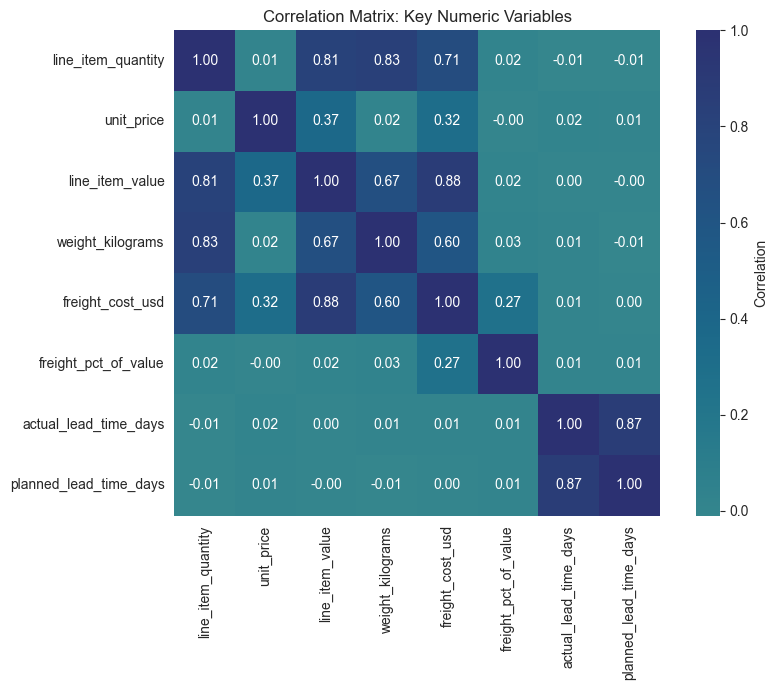


 Strongest relationships (top 5, excluding self-correlation) 
freight_cost_usd        line_item_value          0.88
planned_lead_time_days  actual_lead_time_days    0.87
weight_kilograms        line_item_quantity       0.83
line_item_value         line_item_quantity       0.81
freight_cost_usd        line_item_quantity       0.71
dtype: float64

 EDA completed 


In [11]:
# Correlation analysis — relationships between numeric variables
# Use case : Distributions and outliers alone don't tell you how variables relate to each other. 
# This is the step that answers questions like :
# - Does higher quantity mean lower unit price? 
# - Does freight cost scale with shipment weight?
# ---------------------------------------------------------------------
corr_cols = [
    "line_item_quantity", "unit_price", "line_item_value", "weight_kilograms",
    "freight_cost_usd", "freight_pct_of_value", "actual_lead_time_days",
    "planned_lead_time_days"
]
corr_matrix = df[corr_cols].corr().round(2)
print("\n  Correlation matrix : ")
print(corr_matrix)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap="crest", center=0, fmt=".2f",
            square=True, cbar_kws={"label": "Correlation"})
plt.title("Correlation Matrix: Key Numeric Variables")
plt.tight_layout()
plt.savefig("eda_correlation_matrix.png", dpi=120)
plt.show()
plt.close()

# Flag the strongest relationships

corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = corr_upper.unstack().dropna().sort_values(key=abs, ascending=False)
print("\n Strongest relationships (top 5, excluding self-correlation) ")
print(corr_pairs.head(5))

print("\n EDA completed ")